1. Input Data

In [1]:
import numpy as np
import torch

# 读入数据（测试数据）
data = np.load("frozen_soil_sensor_dataset_test_corrected.npz")

all_T        = data["all_T"]         # (n_case, Nt, Nz)   全场温度
all_T_sensor = data["all_T_sensor"]  # (n_case, Nt, n_s)  传感器温度
params_arr   = data["params_arr"]    # (n_case, n_param)  SFCC 参数
curve_ids    = data["curve_ids"]     # (n_case,)
t            = data["t"]             # (Nt,)
z            = data["z"]             # (Nz,)
sensor_z     = data["sensor_z"]      # (n_s,)
sensor_idx   = data["sensor_idx"]    # (n_s,)

print("all_T       :", all_T.shape)
print("all_T_sensor:", all_T_sensor.shape)
print("params_arr  :", params_arr.shape)
print("curve_ids   :", curve_ids.shape)
print("t           :", t.shape)
print("z           :", z.shape)
print("sensor_z    :", sensor_z)
print("sensor_idx  :", sensor_idx)

all_T       : (220, 61, 49)
all_T_sensor: (220, 61, 11)
params_arr  : (220, 6)
curve_ids   : (220,)
t           : (61,)
z           : (49,)
sensor_z    : [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]
sensor_idx  : [ 4  8 12 16 20 24 28 32 36 40 44]


2. 建立 Inverse DeepONet

2.1 转化数据shape

In [2]:
X_sensor_np = all_T_sensor
X_sensor = torch.from_numpy(X_sensor_np).permute(0, 2, 1).float()
params   = torch.from_numpy(params_arr).float()

print("X_sensor for CNN:", X_sensor.shape)
print("params          :", params.shape)


X_sensor for CNN: torch.Size([220, 11, 61])
params          : torch.Size([220, 6])


2.2. 网络架构

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BranchCNN(nn.Module):

    def __init__(self, n_sensors: int, latent_dim: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_sensors, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        # 对时间维做全局平均池化 -> (B, 32)
        self.pool = nn.AdaptiveAvgPool1d(1)  # 捕捉温度平均值
        self.ln   = nn.LayerNorm(32)
        self.fc   = nn.Linear(32, latent_dim)

    def forward(self, x):
        # x: (B, n_sensors, Nt)
        h = self.conv(x)              # (B, 32, Nt)
        h = self.pool(h).squeeze(-1)  # (B, 32)
        h = self.ln(h)
        b = self.fc(h)                # (B, latent_dim = p)
        return b


class TrunkNet(nn.Module):
    
    def __init__(self, latent_dim: int = 64, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim)
        )

    def forward(self, T_query):         
        
        if T_query.dim() == 1:
            x = T_query.unsqueeze(-1)    # (n_T, 1)
        else:
            x = T_query.unsqueeze(-1)
        t = self.net(x)                  # (..., latent_dim)
        return t


class InverseTwoParameter(nn.Module):

    def __init__(
        self,
        n_sensors,
        latent_dim=8,
        theta_sat=0.5,
        theta_res_max=0.4,
        gamma_min=0.0,
        gamma_max=10.0,
    ):
        super().__init__()

        self.branch = BranchCNN(n_sensors, latent_dim)

        self.fc_theta_res = nn.Linear(latent_dim, 1)
        self.fc_gamma = nn.Linear(latent_dim, 1)

        self.theta_sat = theta_sat
        self.theta_res_max = theta_res_max
        self.gamma_min = gamma_min
        self.gamma_max = gamma_max

    def predict_parameters(self, X_sensor):

        b = self.branch(X_sensor)

        theta_res = (
            self.theta_res_max
            * torch.sigmoid(self.fc_theta_res(b))
        )

        gamma = self.gamma_min + (
            self.gamma_max - self.gamma_min
        ) * torch.sigmoid(self.fc_gamma(b))

        return theta_res, gamma

    def forward(self, X_sensor, T_query):

        T_query = T_query.to(X_sensor.device)

        theta_res, gamma = self.predict_parameters(
            X_sensor
        )

        x = torch.clamp(
            -T_query,
            min=0.0
        ).view(1, -1)

        theta = theta_res + (
            self.theta_sat - theta_res
        ) * torch.exp(
            -((x / gamma)**2)
        )

        return theta

3. Connect PDE solver

3.1. K and C_eff functions

In [4]:
import torch.nn as nn
import torch.nn.functional as F

# ===== 物性参数 =====
n_porosity    = 0.5         # 总孔隙度
theta_s_fixed = 1.0 - n_porosity   # 固体体积分数（可以按需要改）

K_s = 8.80*86400       # W/m/K   固体导热率
K_w = 0.56*86400       # W/m/K   水导热率
K_i = 2.26*86400       # W/m/K   冰导热率

C_s = 2.13*1e6         # J/m3/K  固体体积热容
C_w = 4.19e6           # J/m3/K  水体积热容
C_i = 2.13e6           # J/m3/K  冰体积热容

L     = 3.34e5         # J/kg    水的潜热
rho_w = 1000.0         # kg/m3    水的密度


In [5]:
# 工具函数 1：1D 线性插值 θ(T) 或 dθ/dT
def interp_1d(T_nodes: torch.Tensor,
              T_query: torch.Tensor,
              y_query: torch.Tensor) -> torch.Tensor:
    
    T_min, T_max = T_query[0], T_query[-1]
    T_clamp = torch.clamp(T_nodes, T_min, T_max)

    n_T = T_query.shape[0]
    pos = (T_clamp - T_min) / (T_max - T_min) * (n_T - 1)

    idx0 = torch.floor(pos).long()
    idx1 = torch.clamp(idx0 + 1, max=n_T - 1)
    w    = (pos - idx0.float()).clamp(0.0, 1.0)

    y0 = y_query[idx0]
    y1 = y_query[idx1]
    y  = (1.0 - w) * y0 + w * y1
    return y


# 工具函数 2: 在固定 T_query 上 计算 SFCC 及解析导数 dθ/dT
def sfcc_and_deriv_finite_diff_batch(
    deeponet: nn.Module,
    X_sensor_batch: torch.Tensor,  # (B, n_sensors, Nt)
    T_query: torch.Tensor,         # (n_T,)
    eps_T: float = 0.2,
    dtheta_max: float = 5.0
):
    
    device = T_query.device
    X_sensor_batch = X_sensor_batch.to(device)
    T_query = T_query.to(device)

    eps = float(eps_T)
    T_min, T_max = T_query[0], T_query[-1]
    T_plus  = torch.clamp(T_query + eps,  T_min, T_max)
    T_minus = torch.clamp(T_query - eps,  T_min, T_max)

    theta_center = deeponet(X_sensor_batch, T_query)   # (B, n_T)
    theta_plus   = deeponet(X_sensor_batch, T_plus)    # (B, n_T)
    theta_minus  = deeponet(X_sensor_batch, T_minus)   # (B, n_T)

    dtheta = (theta_plus - theta_minus) / (2.0 * eps)  # (B, n_T)
    dtheta = torch.clamp(dtheta, 0.0, dtheta_max)

    return theta_center, dtheta



In [6]:
# 由 θ_w 计算 K(T)，由 θ_w & dθ/dT 计算 C_eff(T)
def compute_K_from_theta(theta_w: torch.Tensor) -> torch.Tensor:
    """
    theta_w : (Nz,)
    返回:
      K_T(T) : (Nz,)
    """
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed

    Ks_part = K_s ** theta_s
    Kw_part = K_w ** theta_w
    Ki_part = K_i ** theta_i

    return Ks_part * Kw_part * Ki_part


def compute_Ceff_from_theta_fdiff(
    theta_w: torch.Tensor,      # (Nz,)
    T_nodes: torch.Tensor,      # (Nz,)
    T_query: torch.Tensor,      # (n_T,)
    dtheta_query: torch.Tensor  # (n_T,)
) -> torch.Tensor:
    """
    C_eff(T) = θ_s C_s + θ_w C_w + θ_i C_i + L ρ_w dθ_w/dT

    输入:
      theta_w     : (Nz,)  当前节点的未冻水体积分数
      T_nodes     : (Nz,)  当前节点温度
      T_query     : (n_T,) DeepONet 的温度网格
      dtheta_query: (n_T,) 在 T_query 上的 dθ/dT
    """
    # 三相体积分数
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed

    # 显热项
    C_T = theta_s * C_s + theta_w * C_w + theta_i * C_i   # (Nz,)

    # 把 dθ/dT 从 T_query 插值到当前节点温度 T_nodes
    dtheta_nodes = interp_1d(T_nodes, T_query, dtheta_query)  # (Nz,)

    # 加潜热项
    C_eff = C_T + L * rho_w * dtheta_nodes
    return C_eff

3.2 PDE solver

In [7]:
def solve_one_case_with_sfcc_fdiff(
    theta_query: torch.Tensor,   # (n_T,)
    dtheta_query: torch.Tensor,  # (n_T,)
    T_query: torch.Tensor,       # (n_T,)
    z: torch.Tensor,             # (Nz,)
    t: torch.Tensor,             # (Nt,)
    T_initial: float,
    T_top_func
) -> torch.Tensor:
    
    device = theta_query.device
    z = z.to(device)
    t = t.to(device)

    dz  = z[1] - z[0]
    dt  = t[1] - t[0]
    Nz  = z.numel()
    Nt  = t.numel()
    dz2 = dz * dz

    # t = 0 时刻的温度向量，作为计算图里的第一个状态
    T0 = torch.full((Nz,), float(T_initial),
                    dtype=torch.float32, device=device)
    T_list = [T0]  # 长度 Nt 的列表，每个元素 (Nz,)

    for n in range(Nt - 1):
        Tn = T_list[-1]   

        time_n1     = float(t[n+1].item())
        T_top_n1    = float(T_top_func(time_n1))

        # === 1) 用 DeepONet 的 θ(T)、dθ/dT 计算物性 ==========
        theta_w = interp_1d(Tn, T_query, theta_query)   # (Nz,)
        K_T     = compute_K_from_theta(theta_w)         # (Nz,)
        C_eff   = compute_Ceff_from_theta_fdiff(
            theta_w, Tn, T_query, dtheta_query
        )                                               # (Nz,)

        # 节点间导热系数
        K_half = 0.5 * (K_T[1:] + K_T[:-1])            # (Nz-1,)

        # === 2) 组装线性方程 A * T_internal = d_vec ==========
        M = Nz - 2  # 内点个数

        a = torch.zeros(M-1, device=device)
        b = torch.zeros(M,   device=device)
        c = torch.zeros(M-1, device=device)
        d_vec = torch.zeros(M, device=device)

        for j in range(1, Nz-1):
            m = j - 1

            # 与 模拟一致：j==1 仍然用 K_half[j-1]
            K_left  = K_half[j-1]     # K_{j-1/2}
            K_right = K_half[j]       # K_{j+1/2}
            Ci      = C_eff[j]

            a_m = -K_left  / dz2
            c_m = -K_right / dz2
            b_m = Ci / dt + (K_left + K_right) / dz2
            d_m = Ci / dt * Tn[j]

            if j == 1:
                b_m = b_m + a_m

            if j == Nz-2:
                d_m -= c_m * T_top_n1

            b[m]     = b_m
            d_vec[m] = d_m
            if m > 0:
                a[m-1] = a_m
            if m < M-1:
                c[m] = c_m


        # === 3) 可微的线性求解器 ============================
        A = torch.diag(b) + torch.diag(a, diagonal=-1) + torch.diag(c, diagonal=1)
        T_internal = torch.linalg.solve(A, d_vec)   # (M,)

        # === 4) 拼出下一时刻的整体温度向量 T_next ==========
        T_next = torch.empty_like(Tn)
        T_next[1:-1] = T_internal
        T_next[0]    = T_next[1]   # zero-flux
        T_next[-1]   = T_top_n1

        # 放进列表，后面时间步会用到
        T_list.append(T_next)

    # 最后 stack 成 (Nt, Nz)
    T_field = torch.stack(T_list, dim=0)   # (Nt, Nz)
    return T_field


3.3 Connect DeepONet and PDE

In [8]:
class FrozenSoilDM(nn.Module):
    
    def __init__(self,
                 deeponet: nn.Module,
                 z_grid,
                 t_grid,
                 sensor_idx,
                 T_top_func,
                 T_initial: float,
                 theta_sat: float = 0.5,
                 T_min: float = -15.0,
                 T_max: float = 0.0,
                 n_T_query: int = 100):
        super().__init__()

        self.deeponet       = deeponet
        self.T_initial      = T_initial
        self.T_top_func     = T_top_func
        self.theta_sat      = theta_sat

        # 网格和传感器索引
        z_grid = np.asarray(z_grid, dtype=np.float32)
        t_grid = np.asarray(t_grid, dtype=np.float32)
        self.register_buffer("z", torch.from_numpy(z_grid))
        self.register_buffer("t", torch.from_numpy(t_grid))
        self.register_buffer(
            "sensor_idx",
            torch.as_tensor(sensor_idx, dtype=torch.long)
        )

        # DeepONet 评估 SFCC 的温度网格
        T_query_np = np.linspace(T_min, T_max, n_T_query).astype("float32")
        self.register_buffer("T_query", torch.from_numpy(T_query_np))

    def forward(self, X_sensor: torch.Tensor):
        """
        X_sensor: (B, n_sensors, Nt_obs)

        返回:
          T_all    : (B, Nt, Nz)
          T_sensor : (B, Nt, n_sensors)
        """
        device = X_sensor.device
        B, n_sensors, Nt_obs = X_sensor.shape

        z       = self.z.to(device)
        t       = self.t.to(device)
        T_query = self.T_query.to(device)
        idx_s   = self.sensor_idx.to(device)

        Nz = z.numel()
        Nt = t.numel()
        assert Nt_obs == Nt, "观测时间步数 Nt_obs 必须与 t_grid 的 Nt 一致"

        # ===== 先对整个 batch 一次性计算 SFCC 和导数 =====
        theta_batch, dtheta_batch = sfcc_and_deriv_finite_diff_batch(
            self.deeponet,
            X_sensor,    # (B, n_sensors, Nt)
            T_query,     # (n_T,)
            eps_T=0.2,
            dtheta_max=5.0
        )  # (B, n_T), (B, n_T)

        T_fields = []
        for b in range(B):
            T_field = solve_one_case_with_sfcc_fdiff(
               theta_query=theta_batch[b],
               dtheta_query=dtheta_batch[b],
               T_query=T_query,
               z=z, t=t,
               T_initial=self.T_initial,
               T_top_func=self.T_top_func
            )
            T_fields.append(T_field)

        T_all = torch.stack(T_fields, dim=0)     # (B, Nt, Nz)
        # 提取传感器位置温度
        T_sensor = T_all[:, :, idx_s]   # (B, Nt, n_sensors)

        return T_all, T_sensor


4. 加载 DeepONet

In [9]:
import torch
import numpy as np

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

n_case, n_sensors, Nt = X_sensor.shape
latent_dim = 8
theta_sat = 0.5

deeponet_eval = InverseTwoParameter(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=theta_sat,
    theta_res_max=0.4,
    gamma_min=0.0,
    gamma_max=10.0,
).to(device)

model_path = (
    r"D:\UW Madsion\Operator\SFC_inverse\Operator experiment"
    r"\SC_DION\Baseline_two parameter_Train_80"
    r"\Train_process_two parameter_train80"
    r"\two_parameter_operator_train_80.pt"
)

state_dict = torch.load(
    model_path,
    map_location=device
)

deeponet_eval.load_state_dict(state_dict)
deeponet_eval.eval()

n_trainable = sum(
    p.numel()
    for p in deeponet_eval.parameters()
    if p.requires_grad
)

print("Loaded two-parameter baseline.")
print("Trainable parameters:", n_trainable)

Using device: cuda
Loaded two-parameter baseline.
Trainable parameters: 3834


5. Generalization B

5.1. Scattering plot for temp field

In [10]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

deeponet_eval.eval()

all_pred = []
all_true = []

T_field_all = [] 

# boundary and initial condition
T_initial = -15.0  

def T_top(time_day: float) -> float:
    if time_day <= 0.5:
        return -5.0
    elif time_day <= 5.0:
        return 0.0

T_query = torch.linspace(-15, 0, 50).to(device)
z = torch.from_numpy(z).float().to(device)
t = torch.from_numpy(t).float().to(device)

with torch.no_grad():
    for i in range(n_case):

        # ---------- 1. inverse operator ----------
        # X_sensor[i]: (n_sensors, Nt)
        theta_query_b, dtheta_query_b = sfcc_and_deriv_finite_diff_batch(
           deeponet=deeponet_eval,
           X_sensor_batch=X_sensor[i].unsqueeze(0).to(device),
           T_query=T_query,
           eps_T=0.2,          # 和你训练/生成数据时一致
           dtheta_max=5.0
           )
        
        theta_query  = theta_query_b.squeeze(0)      # (n_T,)
        dtheta_query = dtheta_query_b.squeeze(0)     # (n_T,)

        # ---------- 2. PDE solver ----------
        T_field = solve_one_case_with_sfcc_fdiff(
            theta_query=theta_query,
            dtheta_query=dtheta_query,
            T_query=T_query,
            z=z,
            t=t,
            T_initial=T_initial,
            T_top_func=T_top
        )  # (Nt, Nz)

        T_field_all.append(T_field.cpu()) 

        # ---------- 3. extract sensor data ----------
        T_pred_sensor = T_field[:, sensor_idx]  # (Nt, n_sensors)

        all_pred.append(T_pred_sensor.cpu().numpy())
        all_true.append(all_T_sensor[i])

T_field_all = torch.stack(T_field_all, dim=0)

# ---------- 4. stack ----------
y_pred = np.concatenate(all_pred, axis=0).ravel()
y_true = np.concatenate(all_true, axis=0).ravel()

# ---------- 5. metrics ----------
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")


RMSE = 0.1068
R2   = 0.9993


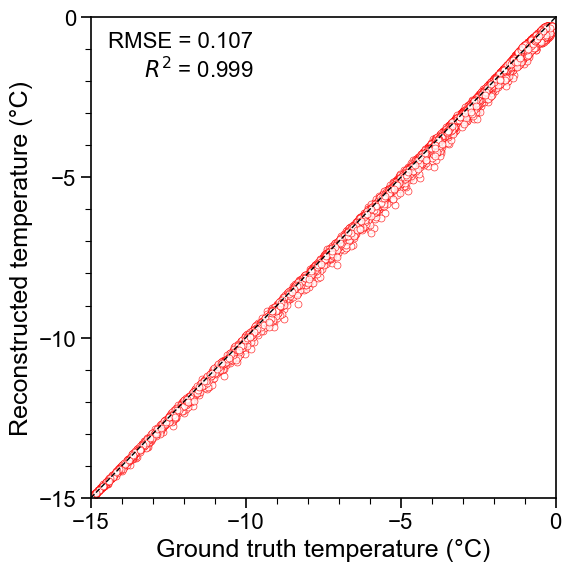

In [11]:
# ---------- 6. scatter ----------
stride = 15 
y_true_p = y_true[::stride]
y_pred_p = y_pred[::stride]

import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

# ---------- 全局字体设置 ----------
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 16
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["xtick.labelsize"] = 16
mpl.rcParams["ytick.labelsize"] = 16
mpl.rcParams["legend.fontsize"] = 14

# ---------- 画图 ----------
fig, ax = plt.subplots(figsize=(6, 6))

# 散点
ax.scatter(
    y_true_p, y_pred_p,
    s=25,
    facecolors="white",     # 白色填充
    edgecolors="red",       # 红色边框
    linewidths=0.5,
    alpha=0.8,
    rasterized=True         
)

# y=x 参考线
ax.plot(
    [-15, 0], [-15, 0],
    linestyle="--",
    color="black",
    linewidth=1.0
)

# ---------- 坐标范围 ----------
ax.set_xlim(-15, 0)
ax.set_ylim(-15, 0)

# ---------- 刻度 ----------
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(1))

ax.tick_params(which="major", length=7, width=1.2)
ax.tick_params(which="minor", length=4, width=0.8)

# ---------- 坐标轴标签 ----------
ax.set_xlabel("Ground truth temperature (°C)")
ax.set_ylabel("Reconstructed temperature (°C)")

# ---------- RMSE / R2 ----------
ax.text(
    0.35, 0.03 + 0.94,
    f"RMSE = {rmse:.3f}\n$R^2$ = {r2:.3f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=16
)

# ---------- 边框美化 ----------
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.grid(False)
plt.tight_layout()
plt.show()

Box plot data (RMSE & R2)

In [12]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

deeponet_eval.eval()

rmse_case = []
r2_case   = []

# boundary and initial condition
T_initial = -15.0  

def T_top(time_day: float) -> float:
    if time_day <= 0.5:
        return -5.0
    elif time_day <= 5.0:
        return 0.0

T_query = torch.linspace(-15, 0, 50).to(device)
#z = torch.from_numpy(z).float().to(device)
#t = torch.from_numpy(t).float().to(device)

with torch.no_grad():
    for i in range(n_case):

        # ---------- 1. inverse operator ----------
        theta_q, dtheta_q = sfcc_and_deriv_finite_diff_batch(
            deeponet=deeponet_eval,
            X_sensor_batch=X_sensor[i].unsqueeze(0).to(device),
            T_query=T_query,
            eps_T=0.2,
            dtheta_max=5.0
        )
        theta_q  = theta_q.squeeze(0)
        dtheta_q = dtheta_q.squeeze(0)

        # ---------- 2. PDE solver ----------
        T_field = solve_one_case_with_sfcc_fdiff(
            theta_query=theta_q,
            dtheta_query=dtheta_q,
            T_query=T_query,
            z=z,
            t=t,
            T_initial=T_initial,
            T_top_func=T_top
        )  # (Nt, Nz)

        # ---------- 3. extract sensor data ----------
        y_pred = T_field[:, sensor_idx].cpu().numpy().ravel()
        y_true = np.asarray(all_T_sensor[i]).ravel()

        # ---------- 4. per-case metrics ----------
        rmse_case.append(np.sqrt(mean_squared_error(y_true, y_pred)))

        # R2 safeguard for near-constant case
        if np.var(y_true) < 1e-12:
            r2_case.append(np.nan)
        else:
            r2_case.append(r2_score(y_true, y_pred))

# ---------- 5. save for boxplot ----------
rmse_case = np.asarray(rmse_case)
r2_case   = np.asarray(r2_case)

np.savez(
    "temperature_boxplot_test_two_parameter_N80.npz",
    rmse=rmse_case,
    r2=r2_case
)

print("Saved per-case RMSE & R2 for boxplot (N=80)")

Saved per-case RMSE & R2 for boxplot (N=80)


5.2. Comparsion of SFCC curves

5.2.1 Ground truth

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

theta_sat = 0.5  

param_cols = ["form_id", "alpha", "beta", "theta_res", "gamma", "n"]
params_df = pd.DataFrame(params_arr, columns=param_cols)
params_df["curve_id"] = curve_ids
print(params_df.head())


   form_id  alpha  beta  theta_res     gamma    n  curve_id
0      2.0    0.0   0.0   0.099743  1.430308  0.0         1
1      2.0    0.0   0.0   0.101682  0.833243  0.0         2
2      2.0    0.0   0.0   0.098324  0.501503  0.0         3
3      2.0    0.0   0.0   0.176258  0.801955  0.0         4
4      2.0    0.0   0.0   0.172534  0.616955  0.0         5


In [14]:
def theta_power_law(T, alpha, beta, theta_sat=0.5):
    T = np.asarray(T, dtype=float)
    x = np.maximum(-T, 1e-6)
    val = alpha * x**beta
    return np.clip(val, 0.0, theta_sat)

# θ = θ_res + (θ_sat - θ_res) * exp(-((T - T0)/γ)^2)
def theta_exponential(T, theta_res, gamma, theta_sat=0.5, T0=0.0):
    T = np.asarray(T, dtype=float)
    val = theta_res + (theta_sat - theta_res) * np.exp(-((T - T0) / gamma)**2)
    return np.clip(val, 0.0, theta_sat)

# VG
def theta_vg(T, theta_res, alpha, n, theta_sat=0.5):
    T = np.asarray(T, dtype=float)
    x = np.maximum(-T, 1e-6)   # 防止 0
    m = 1.0 - 1.0 / n
    val = theta_res + (theta_sat - theta_res) * (1.0 + (alpha * x)**n)**(-m)
    return np.clip(val, 0.0, theta_sat)

# 统一接口
def theta_w(T, param_row, theta_sat=0.5):
    
    form = int(param_row["form_id"])  # 1, 2, or 3

    if form == 1:
        return theta_power_law(
            T,
            param_row["alpha"],
            param_row["beta"],
            theta_sat=theta_sat,
        )

    elif form == 2:
        return theta_exponential(
            T,
            param_row["theta_res"],
            param_row["gamma"],
            theta_sat=theta_sat,
            T0 = 0.0
        )

    elif form == 3:
        return theta_vg(
            T,
            param_row["theta_res"],
            param_row["alpha"],
            param_row["n"],
            theta_sat=theta_sat
        )
        
    else:
        raise ValueError(f"未知 form_id={form}，期望是 1/2/3")


In [15]:
# 评估用温度网格（和训练范围一致即可）
T_eval_np = np.linspace(-15.0, 0.0, 50).astype("float32")
n_T_eval = T_eval_np.shape[0]
n_case = params_arr.shape[0]

theta_true_np = np.zeros((n_case, n_T_eval), dtype=np.float32)

for i in range(n_case):
    row = params_df.iloc[i]
    theta_true_np[i] = theta_w(T_eval_np, row, theta_sat=theta_sat)

print("theta_true_np shape:", theta_true_np.shape)   # (n_case, 50)


theta_true_np shape: (220, 50)


5.2.2 DeepONet 反演 SFCC

In [16]:
import time
import torch

# ---------------------------------------------------------
# Prepare model and input data
# ---------------------------------------------------------
deeponet_eval.eval()

T_eval = (
    torch.from_numpy(T_eval_np)
    .float()
    .to(device)
)

X_eval = X_sensor.to(device)

n_case = X_eval.shape[0]

# ---------------------------------------------------------
# GPU warm-up: excluded from inference time
# ---------------------------------------------------------
with torch.no_grad():
    _ = deeponet_eval(
        X_eval,
        T_eval,
    )

if device.type == "cuda":
    torch.cuda.synchronize()

# ---------------------------------------------------------
# Measure inference time
# Temperature observations -> complete SFCCs
# ---------------------------------------------------------
inference_start = time.perf_counter()

with torch.no_grad():
    theta_pred = deeponet_eval(
        X_eval,
        T_eval,
    )

if device.type == "cuda":
    torch.cuda.synchronize()

inference_time = (
    time.perf_counter()
    - inference_start
)

# ---------------------------------------------------------
# Recover the two predicted parameters
# This operation is excluded from the SFCC inference time
# ---------------------------------------------------------
with torch.no_grad():
    theta_res_pred, gamma_pred = (
        deeponet_eval.predict_parameters(
            X_eval
        )
    )

# ---------------------------------------------------------
# Move results to CPU after timing
# ---------------------------------------------------------
theta_pred_np = (
    theta_pred
    .detach()
    .cpu()
    .numpy()
)

theta_res_pred_np = (
    theta_res_pred
    .squeeze(1)
    .detach()
    .cpu()
    .numpy()
)

gamma_pred_np = (
    gamma_pred
    .squeeze(1)
    .detach()
    .cpu()
    .numpy()
)

# ---------------------------------------------------------
# Report inference time
# ---------------------------------------------------------
print(
    f"Inference time for {n_case} test cases: "
    f"{inference_time * 1000:.3f} ms"
)

print(
    f"Average inference time per case: "
    f"{inference_time / n_case * 1000:.6f} ms"
)

print(
    "theta_pred_np shape:",
    theta_pred_np.shape,
)

print(
    "theta_res_pred_np shape:",
    theta_res_pred_np.shape,
)

print(
    "gamma_pred_np shape:",
    gamma_pred_np.shape,
)

Inference time for 220 test cases: 1.195 ms
Average inference time per case: 0.005431 ms
theta_pred_np shape: (220, 50)
theta_res_pred_np shape: (220,)
gamma_pred_np shape: (220,)


In [17]:
# 每个 case 上的 MSE / RMSE
# =========================
# 全局：RMSE + R2
# =========================
err_all = theta_pred_np - theta_true_np  # (n_case, n_T)

# RMSE
sfcc_mse_case = np.mean(err_all**2, axis=1)  # (n_case,)
sfcc_rmse_case = np.sqrt(sfcc_mse_case)

# R2
ss_res_all = np.sum(err_all**2, axis=1)
theta_mean_all = np.mean(theta_true_np, axis=1, keepdims=True)
ss_tot_all = np.sum((theta_true_np - theta_mean_all)**2, axis=1)
sfcc_r2_case = 1.0 - ss_res_all / ss_tot_all

print("SFCC (ALL T):")
print("  RMSE mean / min / max = "
      f"{sfcc_rmse_case.mean():.4f}, "
      f"{sfcc_rmse_case.min():.4f}, "
      f"{sfcc_rmse_case.max():.4f}")
print("  R2   mean / min / max = "
      f"{sfcc_r2_case.mean():.4f}, "
      f"{sfcc_r2_case.min():.4f}, "
      f"{sfcc_r2_case.max():.4f}")


# =========================
# 近融点：[-2.5, 0] RMSE + R2（per-case）
# =========================
T = T_eval_np
mask_warm = (T > -2.5) & (T <= 0.0)   # [-2.5, 0]
assert mask_warm.any(), "No temperature points in [-2.5, 0]"

err_warm = theta_pred_np[:, mask_warm] - theta_true_np[:, mask_warm]
theta_true_warm = theta_true_np[:, mask_warm]

# RMSE
sfcc_mse_case_warm = np.mean(err_warm**2, axis=1)
sfcc_rmse_case_warm = np.sqrt(sfcc_mse_case_warm)

# R2
ss_res_warm = np.sum(err_warm**2, axis=1)
theta_mean_warm = np.mean(theta_true_warm, axis=1, keepdims=True)
ss_tot_warm = np.sum((theta_true_warm - theta_mean_warm)**2, axis=1)
sfcc_r2_case_warm = 1.0 - ss_res_warm / ss_tot_warm

print("SFCC (T in [-2.5, 0]):")
print("  RMSE mean / min / max = "
      f"{sfcc_rmse_case_warm.mean():.4f}, "
      f"{sfcc_rmse_case_warm.min():.4f}, "
      f"{sfcc_rmse_case_warm.max():.4f}")
print("  R2   mean / min / max = "
      f"{sfcc_r2_case_warm.mean():.4f}, "
      f"{sfcc_r2_case_warm.min():.4f}, "
      f"{sfcc_r2_case_warm.max():.4f}")

SFCC (ALL T):
  RMSE mean / min / max = 0.0136, 0.0002, 0.0528
  R2   mean / min / max = 0.9038, -0.3847, 1.0000
SFCC (T in [-2.5, 0]):
  RMSE mean / min / max = 0.0144, 0.0001, 0.0538
  R2   mean / min / max = 0.9721, 0.7104, 1.0000


In [18]:
# 所有测试样本和温度点一起计算
err_global = theta_pred_np - theta_true_np

sfcc_rmse_global = np.sqrt(np.mean(err_global**2))

ss_res_global = np.sum(err_global**2)
ss_tot_global = np.sum(
    (theta_true_np - np.mean(theta_true_np))**2
)
sfcc_r2_global = 1.0 - ss_res_global / ss_tot_global

print("Global SFCC RMSE =", sfcc_rmse_global)
print("Global SFCC R2   =", sfcc_r2_global)

Global SFCC RMSE = 0.01697286
Global SFCC R2   = 0.9742967933416367


Box plot data

In [19]:
# =========================
# 保存：SFCC 箱型图数据（per-case）
# =========================
np.savez(
    "sfcc_case_plots_two_parameter_test_80.npz",
    rmse_allT=sfcc_rmse_case,          # (n_case,)
    r2_allT=sfcc_r2_case,              # (n_case,)
    rmse_warm=sfcc_rmse_case_warm,     # (n_case,)  T in [-2.5, 0]
    r2_warm=sfcc_r2_case_warm,         # (n_case,)
    T_eval=T_eval_np                   # (n_T,) 方便后面复现mask/检查
)

print("Saved SFCC per-case RMSE & R2 for boxplot (N=80)")

Saved SFCC per-case RMSE & R2 for boxplot (N=80)


5.2.3. Error distribution

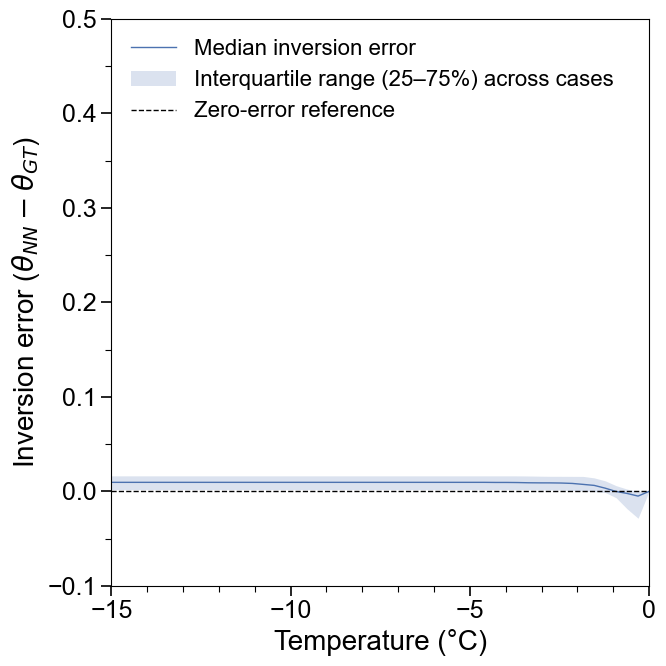

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ================= 全局字体 =================
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 18
mpl.rcParams["axes.labelsize"] = 20
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
mpl.rcParams["legend.fontsize"] = 16

T = T_eval_np
form_ids = params_df["form_id"].astype(int).to_numpy()

colors = {
    1: "#2C7BB6",  # deep blue
    2: "#4C72B0",  # muted blue
    3: "#59A14F",  # olive green
}

fig, ax = plt.subplots(figsize=(7, 7))

for fid in [2]:
    idx = np.where(form_ids == fid)[0]

    diff = theta_pred_np - theta_true_np
    diff_f = diff[idx]   # (N, n_T)

    q25 = np.percentile(diff_f, 25, axis=0)
    q50 = np.percentile(diff_f, 50, axis=0)
    q75 = np.percentile(diff_f, 75, axis=0)

    # ===== 误差带 =====
    ax.fill_between(
        T, q25, q75,
        color=colors[fid],
        alpha=0.2,
        linewidth=0
    )

    # ===== 中位数 =====
    ax.plot(
        T, q50,
        color=colors[fid],
        linewidth=1.0,
        label=f"Form {fid}"
    )

# ===== 零误差参考线 =====
ax.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.0
)

# ===== 坐标轴 =====
ax.set_xlim(-15, 0)
ax.set_ylim(-0.1, 0.5)

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(which="major", length=7, width=1.2)
ax.tick_params(which="minor", length=4, width=0.8)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Inversion error ($\\theta_{NN} - \\theta_{GT}$)")
ax.yaxis.set_minor_locator(MultipleLocator(0.05))

# ===== 图例 =====
legend_elements = [
    Line2D(
        [0], [0],
        color=colors[2],
        lw=1.0,
        label="Median inversion error"
    ),
    Patch(
        facecolor=colors[2],
        alpha=0.2,
        label="Interquartile range (25–75%) across cases"
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=1.0,
        linestyle="--",
        label="Zero-error reference"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=False
)

ax.grid(False)
plt.tight_layout()
plt.show()

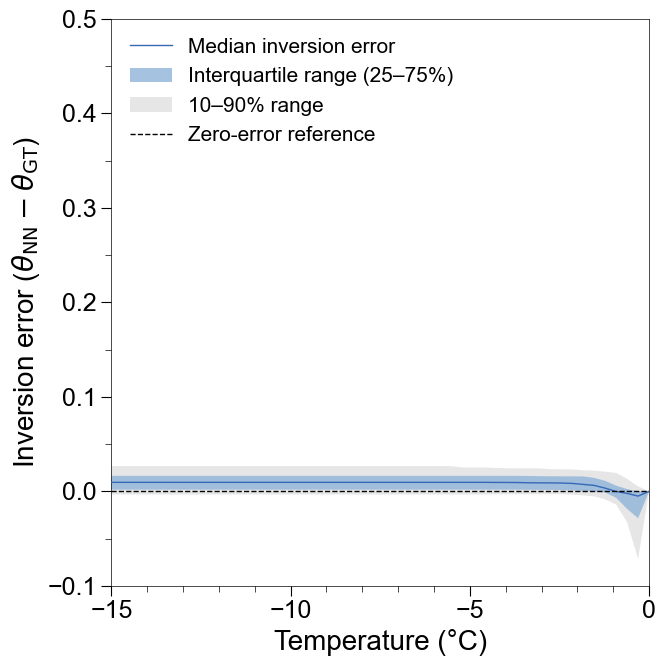

Temperature-dependent signed SFCC inversion error:
[-15, -5) °C: median = 0.0096, IQR = [0.0018, 0.0165], 10–90% range = [-0.0033, 0.0267]
[-5, -1) °C: median = 0.0087, IQR = [0.0010, 0.0159], 10–90% range = [-0.0036, 0.0244]
[-1, 0) °C: median = -0.0015, IQR = [-0.0142, 0.0020], 10–90% range = [-0.0365, 0.0158]

Detailed statistics near 0 °C:
T = -0.918 °C: median = -0.0001, IQR = [-0.0068, 0.0060], 10–90% = [-0.0139, 0.0196]
T = -0.612 °C: median = -0.0022, IQR = [-0.0185, 0.0024], 10–90% = [-0.0326, 0.0133]
T = -0.306 °C: median = -0.0050, IQR = [-0.0284, -0.0000], 10–90% = [-0.0715, 0.0053]
T =  0.000 °C: median = 0.0000, IQR = [0.0000, 0.0000], 10–90% = [0.0000, 0.0000]


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# =========================================================
# 1. Plot settings
# =========================================================
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 18
mpl.rcParams["axes.labelsize"] = 20
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
mpl.rcParams["legend.fontsize"] = 15

T = np.asarray(T_eval_np).ravel()

# =========================================================
# 2. Signed SFCC inversion error
#    shape: (number of test cases, number of temperatures)
# =========================================================
signed_error = theta_pred_np - theta_true_np

q10 = np.percentile(signed_error, 10, axis=0)
q25 = np.percentile(signed_error, 25, axis=0)
q50 = np.percentile(signed_error, 50, axis=0)
q75 = np.percentile(signed_error, 75, axis=0)
q90 = np.percentile(signed_error, 90, axis=0)

# =========================================================
# 3. Colors and adjustable plotting parameters
# =========================================================
median_color = "#3569B7"
inner_color  = "#8FB3D9"   # 25–75%
outer_color  = "#D9D9D9"   # 10–90%

line_width = 1.0
frame_width = 0.5

inner_alpha = 0.80
outer_alpha = 0.65

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(7, 7))

# 10–90% range
ax.fill_between(
    T,
    q10,
    q90,
    facecolor=outer_color,
    alpha=outer_alpha,
    linewidth=0,
    zorder=1
)

# 25–75% interquartile range
ax.fill_between(
    T,
    q25,
    q75,
    facecolor=inner_color,
    alpha=inner_alpha,
    linewidth=0,
    zorder=2
)

# Median signed inversion error
ax.plot(
    T,
    q50,
    color=median_color,
    linewidth=line_width,
    zorder=3
)

# Zero-error reference
ax.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=line_width,
    zorder=4
)

# =========================================================
# 5. Axes
# =========================================================
ax.set_xlim(-15, 0)
ax.set_ylim(-0.10, 0.50)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel(
    r"Inversion error ($\theta_{\mathrm{NN}}-\theta_{\mathrm{GT}}$)"
)

# Major ticks
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(0.1))

# Minor ticks
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))

# Ticks outside
ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=7,
    width=0.8,
    top=False,
    right=False
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="out",
    length=4,
    width=0.5,
    top=False,
    right=False
)

# Frame
for spine in ax.spines.values():
    spine.set_linewidth(frame_width)

ax.grid(False)

# =========================================================
# 6. Legend
# =========================================================
legend_elements = [
    Line2D(
        [0], [0],
        color=median_color,
        linewidth=line_width,
        label="Median inversion error"
    ),
    Patch(
        facecolor=inner_color,
        alpha=inner_alpha,
        label="Interquartile range (25–75%)"
    ),
    Patch(
        facecolor=outer_color,
        alpha=outer_alpha,
        label="10–90% range"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=line_width,
        label="Zero-error reference"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

# =========================================================
# 7. Numerical summary for different temperature intervals
# =========================================================
temperature_ranges = [
    ("[-15, -5)", (T >= -15.0) & (T < -5.0)),
    ("[-5, -1)",  (T >= -5.0)  & (T < -1.0)),
    ("[-1, 0)",   (T >= -1.0)  & (T < 0.0)),
]

print("Temperature-dependent signed SFCC inversion error:")

for label, mask in temperature_ranges:

    interval_error = signed_error[:, mask].ravel()

    print(
        f"{label} °C: "
        f"median = {np.median(interval_error):.4f}, "
        f"IQR = [{np.percentile(interval_error, 25):.4f}, "
        f"{np.percentile(interval_error, 75):.4f}], "
        f"10–90% range = "
        f"[{np.percentile(interval_error, 10):.4f}, "
        f"{np.percentile(interval_error, 90):.4f}]"
    )

# =========================================================
# 8. Near-zero-temperature summary at each query point
# =========================================================
near_zero_mask = (T >= -1.0) & (T <= 0.0)

print("\nDetailed statistics near 0 °C:")

for j in np.where(near_zero_mask)[0]:

    print(
        f"T = {T[j]:6.3f} °C: "
        f"median = {q50[j]:.4f}, "
        f"IQR = [{q25[j]:.4f}, {q75[j]:.4f}], "
        f"10–90% = [{q10[j]:.4f}, {q90[j]:.4f}]"
    )

5.2.4. 308 comparsion curves

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator


# ---------- 输出文件夹 ----------
out_dir = "sfcc_case_plots_test_80"
os.makedirs(out_dir, exist_ok=True)

# ---------- 画图风格 ----------
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["legend.fontsize"] = 12

T = np.asarray(T_eval_np).ravel()
n_case = theta_true_np.shape[0]

for i in range(n_case):
    gt = theta_true_np[i]
    pr = theta_pred_np[i]

    # ===== 计算 RMSE & R2（per case，全温区）=====
    err = pr - gt
    rmse = np.sqrt(np.mean(err**2))

    ss_res = np.sum(err**2)
    ss_tot = np.sum((gt - gt.mean())**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    fig, ax = plt.subplots(figsize=(4.0, 4.0))

    ax.plot(T, gt, linewidth=1.0, label="Ground truth")
    ax.plot(T, pr, linewidth=1.0, linestyle="--", label="Prediction")

    # 你的要求
    ax.grid(False)
    ax.set_xlim(-15, 0)
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.set_ylim(0.0, 0.6)
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Unfrozen water content")

    # 图例
    ax.legend(frameon=False, loc="upper left")

    # ===== 在图例右边显示 RMSE / R2 =====
    ax.text(
        0.36, 0.80,
        f"RMSE = {rmse:.3f}\n$R^2$ = {r2:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10
    )

    # 文件名
    cid = curve_ids[i] if "curve_ids" in globals() else i
    ax.text(
    0.97, 0.97,
    f"ID = {cid}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=12,
    fontweight="bold"
    )
    if "params_df" in globals() and "form_id" in params_df.columns:
        fid = int(params_df.loc[i, "form_id"])
        fname = f"case_{i:03d}_curve_{cid}_form{fid}.png"
    else:
        fname = f"case_{i:03d}_curve_{cid}.png"

    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, fname), dpi=300, bbox_inches="tight")
    plt.close(fig)

print(f"Saved {n_case} figures to: {out_dir}")

Saved 220 figures to: sfcc_case_plots_test_80


5.2.5. Representative cases with different inversion errors

Selected representative cases:
Lower-error case: array index = 169, curve ID = 170, SFCC RMSE = 0.0035, SFCC R2 = 0.9988, Temperature R2 = 1.0000
Median-error case: array index = 74, curve ID = 75, SFCC RMSE = 0.0123, SFCC R2 = 0.9491, Temperature R2 = 1.0000
Higher-error case: array index = 193, curve ID = 194, SFCC RMSE = 0.0262, SFCC R2 = 0.8925, Temperature R2 = 0.9986


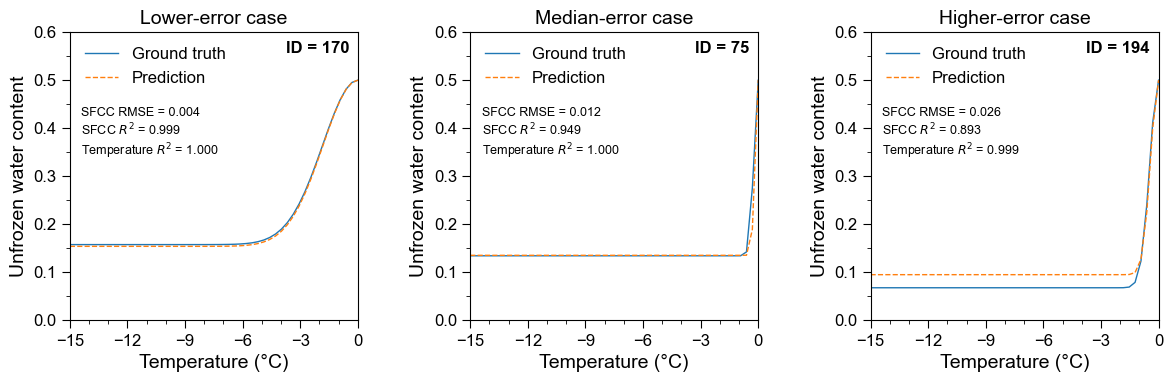

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from sklearn.metrics import r2_score

# =========================================================
# 1. Calculate case-wise SFCC metrics
# =========================================================
T = np.asarray(T_eval_np).ravel()

sfcc_error_all = theta_pred_np - theta_true_np

sfcc_rmse_case = np.sqrt(
    np.mean(sfcc_error_all**2, axis=1)
)

sfcc_ss_res_case = np.sum(
    sfcc_error_all**2,
    axis=1
)

theta_true_mean = np.mean(
    theta_true_np,
    axis=1,
    keepdims=True
)

sfcc_ss_tot_case = np.sum(
    (theta_true_np - theta_true_mean)**2,
    axis=1
)

sfcc_r2_case = np.where(
    sfcc_ss_tot_case > 0,
    1.0 - sfcc_ss_res_case / sfcc_ss_tot_case,
    np.nan
)

# =========================================================
# 2. Select the 10th-, 50th-, and 90th-percentile cases
# =========================================================
sorted_idx = np.argsort(sfcc_rmse_case)
n_test = len(sorted_idx)

idx_p10 = sorted_idx[
    int(round(0.10 * (n_test - 1)))
]

idx_p50 = sorted_idx[
    int(round(0.50 * (n_test - 1)))
]

idx_p90 = sorted_idx[
    int(round(0.90 * (n_test - 1)))
]

selected_cases = [
    ("Lower-error case", idx_p10),
    ("Median-error case", idx_p50),
    ("Higher-error case", idx_p90),
]

# Convert sensor indices to NumPy
if hasattr(sensor_idx, "detach"):
    sensor_idx_np = (
        sensor_idx.detach()
        .cpu()
        .numpy()
        .astype(int)
    )
else:
    sensor_idx_np = np.asarray(
        sensor_idx,
        dtype=int
    )

# =========================================================
# 3. Print selected cases and corresponding metrics
# =========================================================
print("Selected representative cases:")

for case_label, i in selected_cases:

    cid = (
        curve_ids[i]
        if "curve_ids" in globals()
        else i
    )

    # Ground-truth sensor temperatures
    T_true_case = np.asarray(
        all_T_sensor[i]
    ).ravel()

    # Reconstructed sensor temperatures
    if hasattr(T_field_all[i], "detach"):
        T_field_case = (
            T_field_all[i]
            .detach()
            .cpu()
            .numpy()
        )
    else:
        T_field_case = np.asarray(
            T_field_all[i]
        )

    T_pred_case = T_field_case[
        :,
        sensor_idx_np
    ].ravel()

    temperature_r2 = r2_score(
        T_true_case,
        T_pred_case
    )

    print(
        f"{case_label}: "
        f"array index = {i}, "
        f"curve ID = {cid}, "
        f"SFCC RMSE = {sfcc_rmse_case[i]:.4f}, "
        f"SFCC R2 = {sfcc_r2_case[i]:.4f}, "
        f"Temperature R2 = {temperature_r2:.4f}"
    )

# =========================================================
# 4. Plot settings
#    Same style as the 220 individual SFCC figures
# =========================================================
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["legend.fontsize"] = 12

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12.0, 4.0)
)

# =========================================================
# 5. Plot the three representative cases
# =========================================================
for ax, (case_label, i) in zip(
    axes,
    selected_cases
):

    # ---------- SFCC data ----------
    theta_true_case = theta_true_np[i]
    theta_pred_case = theta_pred_np[i]

    # ---------- SFCC metrics ----------
    sfcc_error = (
        theta_pred_case
        - theta_true_case
    )

    sfcc_rmse = np.sqrt(
        np.mean(sfcc_error**2)
    )

    sfcc_ss_res = np.sum(
        sfcc_error**2
    )

    sfcc_ss_tot = np.sum(
        (
            theta_true_case
            - theta_true_case.mean()
        )**2
    )

    sfcc_r2 = (
        1.0 - sfcc_ss_res / sfcc_ss_tot
        if sfcc_ss_tot > 0
        else np.nan
    )

    # ---------- Temperature reconstruction metrics ----------
    T_true_case = np.asarray(
        all_T_sensor[i]
    ).ravel()

    if hasattr(T_field_all[i], "detach"):
        T_field_case = (
            T_field_all[i]
            .detach()
            .cpu()
            .numpy()
        )
    else:
        T_field_case = np.asarray(
            T_field_all[i]
        )

    T_pred_case = T_field_case[
        :,
        sensor_idx_np
    ].ravel()

    temperature_r2 = r2_score(
        T_true_case,
        T_pred_case
    )

    # ---------- SFCC curves ----------
    ax.plot(
        T,
        theta_true_case,
        linewidth=1.0,
        label="Ground truth"
    )

    ax.plot(
        T,
        theta_pred_case,
        linewidth=1.0,
        linestyle="--",
        label="Prediction"
    )

    # ---------- Title ----------
    ax.set_title(
        case_label,
        fontsize=14
    )

    # ---------- Axes ----------
    ax.grid(False)

    ax.set_xlim(-15, 0)
    ax.xaxis.set_major_locator(
        MultipleLocator(3)
    )
    ax.xaxis.set_minor_locator(
        MultipleLocator(1)
    )

    ax.set_ylim(0.0, 0.6)
    ax.yaxis.set_major_locator(
        MultipleLocator(0.1)
    )
    ax.yaxis.set_minor_locator(
        MultipleLocator(0.05)
    )

    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel(
        "Unfrozen water content"
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=6
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="out",
        length=3
    )

    # Keep each panel square
    ax.set_box_aspect(1)

    # ---------- Legend ----------
    ax.legend(
        frameon=False,
        loc="upper left"
    )

    # ---------- Metrics ----------
    ax.text(
        0.04,
        0.74,
        f"SFCC RMSE = {sfcc_rmse:.3f}\n"
        f"SFCC $R^2$ = {sfcc_r2:.3f}\n"
        f"Temperature $R^2$ = {temperature_r2:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9
    )

    # ---------- Case ID ----------
    cid = (
        curve_ids[i]
        if "curve_ids" in globals()
        else i
    )

    ax.text(
        0.97,
        0.97,
        f"ID = {cid}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=12,
        fontweight="bold"
    )

# =========================================================
# 6. Layout
# =========================================================
fig.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.16,
    top=0.88,
    wspace=0.32
)

plt.show()

5.3. Four figures

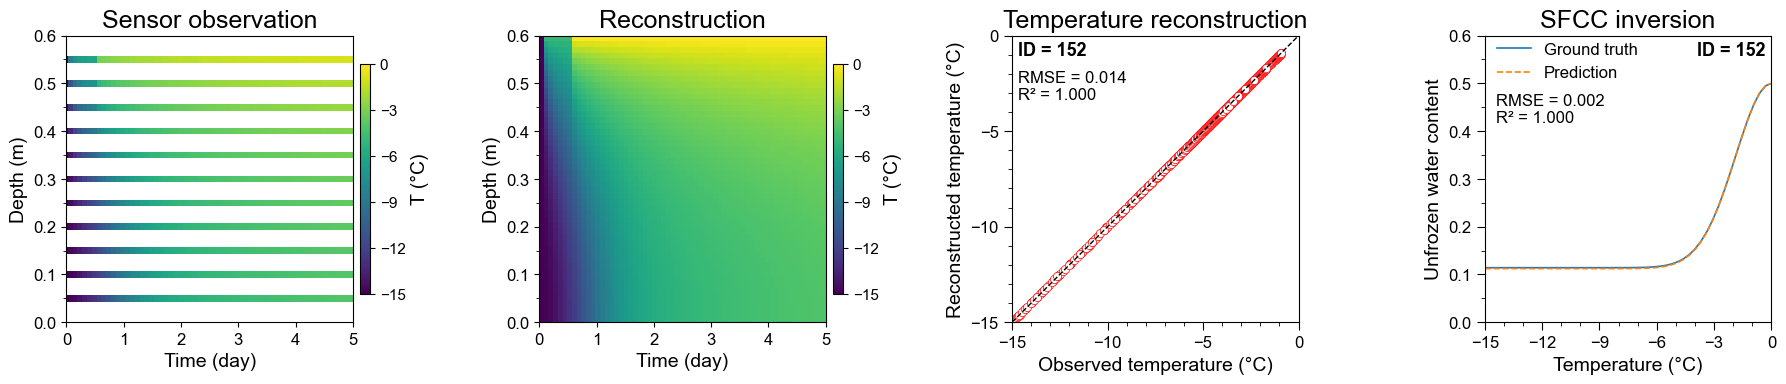

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.ticker import MultipleLocator

# =========================
# 0) case id（0~119）
# =========================
case_id = 151  # 显示 ID=case_id+1 (1~120)

def to_np(x):
    return x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)

# =========================
# 1) numpy data
# =========================
t_np        = to_np(t).ravel()
z_np        = to_np(z).ravel()
sensor_z_np = to_np(sensor_z).ravel()
idx_s       = to_np(sensor_idx).astype(int)

X_sensor_np = to_np(all_T_sensor[case_id])       # (Nt, n_s)
Tfield_np   = to_np(T_field_all[case_id])        # (Nt, Nz)
Y_pred_sensor_np = Tfield_np[:, idx_s]           # (Nt, n_s)

T_eval_np2  = to_np(T_eval_np).ravel()
th_true     = to_np(theta_true_np[case_id]).ravel()
th_pred     = to_np(theta_pred_np[case_id]).ravel()

# =========================
# 2) ranges
# =========================
x0, x1 = 0.0, 5.0
y0, y1 = 0.0, 0.6
Tlo, Thi = -15.0, 0.0

# =========================
# 3) style
# =========================
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["legend.fontsize"] = 12

# =========================
# 4) figure layout
# =========================
fig, axes = plt.subplots(1, 4, figsize=(22.0, 4.8))
fig.subplots_adjust(wspace=0.65)  #

# -------------------------
# helper: inset colorbar
# -------------------------
def add_inset_cbar(mappable, ax, label):
    cax = inset_axes(
        ax, width="3.5%", height="80%",
        loc="center right",
        bbox_to_anchor=(0.06, 0.0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )
    cb = plt.colorbar(mappable, cax=cax)
    cb.set_label(label)
    cb.set_ticks(np.arange(-15, 0.1, 3))   # -15, -12, ..., 0
    cb.ax.set_ylim(-15, 0)
    cb.ax.tick_params(labelsize=11)
    return cb

# ============================================================
# (1) Sensor observation (sparse)
# ============================================================
ax = axes[0]
TT, ZZ = np.meshgrid(t_np, sensor_z_np, indexing="xy")  # (n_s, Nt)
vals   = X_sensor_np.T                                  # (n_s, Nt)

sc = ax.scatter(
    TT.ravel(), ZZ.ravel(),
    c=vals.ravel(),
    s=22, marker="s", linewidths=0.0,
    vmin=-15.0, vmax=0.0
)

ax.set_title("Sensor observation")
ax.set_xlabel("Time (day)")
ax.set_ylabel("Depth (m)")
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_box_aspect(1)
ax.grid(False)

add_inset_cbar(sc, ax, "T (°C)")

# ============================================================
# (2) Reconstruction (PDE field)
# ============================================================
ax = axes[1]
im = ax.imshow(
    Tfield_np.T,
    origin="lower",
    aspect="auto",
    extent=[t_np.min(), t_np.max(), z_np.min(), z_np.max()],
    interpolation="nearest",
    vmin=-15.0, vmax=0.0
)

ax.set_title("Reconstruction")
ax.set_xlabel("Time (day)")
ax.set_ylabel("Depth (m)")
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_box_aspect(1)
ax.grid(False)

add_inset_cbar(im, ax, "T (°C)")

# ============================================================
# (3) Temperature prediction (sensor fit scatter)
# ============================================================
ax = axes[2]

y_true = X_sensor_np.reshape(-1)
y_pred = Y_pred_sensor_np.reshape(-1)

rmse_T = np.sqrt(mean_squared_error(y_true, y_pred))
r2_T   = r2_score(y_true, y_pred)

ax.scatter(
    y_true, y_pred,
    s=35,
    facecolors="white",
    edgecolors="red",
    linewidths=0.5,
    alpha=1.0
)
ax.plot([Tlo, Thi], [Tlo, Thi], "k--", lw=1.0)

ax.set_title("Temperature reconstruction")
ax.set_xlabel("Observed temperature (°C)")
ax.set_ylabel("Reconstructed temperature (°C)")
ax.set_xlim(Tlo, Thi)
ax.set_ylim(Tlo, Thi)

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="both", which="major", length=6)
ax.tick_params(axis="both", which="minor", length=3)

ax.set_box_aspect(1)
ax.grid(False)

# ID + metrics（左上）
ax.text(
    0.02, 0.98, f"ID = {case_id + 1}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13, fontweight="bold"
)
ax.text(
    0.02, 0.88,
    f"RMSE = {rmse_T:.3f}\nR² = {r2_T:.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12
)

# ============================================================
# (4) SFCC inversion (curve + metrics)
# ============================================================
ax = axes[3]
ax.plot(T_eval_np2, th_true, lw=1.2, label="Ground truth")
ax.plot(T_eval_np2, th_pred, lw=1.2, ls="--", label="Prediction")

rmse_sfcc = np.sqrt(mean_squared_error(th_true, th_pred))
r2_sfcc   = r2_score(th_true, th_pred)

ax.set_title("SFCC inversion")
ax.set_xlim(-15, 0)
ax.set_ylim(0.0, 0.6)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Unfrozen water content")

# ID：右上（与你要求一致）
ax.text(
    0.98, 0.98, f"ID = {case_id + 1}",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=13, fontweight="bold"
)

# Legend：左上，与 ID 同一高度；并且与 RMSE 左对齐
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.02, 1.00),
    borderaxespad=0.0
)

# RMSE/R2：放在 legend 下面，左对齐
ax.text(
    0.04, 0.80,
    f"RMSE = {rmse_sfcc:.3f}\nR² = {r2_sfcc:.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12
)

# ticks
ax.xaxis.set_major_locator(MultipleLocator(3))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.tick_params(axis="both", which="major", length=6)
ax.tick_params(axis="both", which="minor", length=3)

ax.set_box_aspect(1)
ax.grid(False)

plt.show()
